<a href="https://colab.research.google.com/github/bajatsira/description-of-life-cycle-processes/blob/main/%D0%A1%D0%B5%D0%BC%D0%B8%D0%BD%D0%B0%D1%8011.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install simpy
!pip install matplotlib

In [4]:
import random
import numpy as np
import simpy
import matplotlib.pyplot as plt


In [5]:
RANDOM_SEED = 42
NUM_CUSTOMERS = 100      # Количество клиентов для обслуживания (START 100)
ARRIVAL_MEAN = 6.5       # Среднее время между прибытиями клиентов (экспоненциальное)

# Инициализируем генератор случайных чисел для воспроизводимости результатов
random.seed(RANDOM_SEED)

In [7]:
class Barber:
    def __init__(self, n, d):
        self.number = n       # Номер мастера (1 или 2)
        self.duration = d     # Границы времени обслуживания [min, max]
        self.usages = 0       # Счетчик обслуженных клиентов

def customer(env, name, barbers, stats):
    arrival_time = env.now

    # Запрашиваем первого освободившегося барбера из Store
    barber = yield barbers.get()

    # Фиксируем время ожидания в очереди
    wait_time = env.now - arrival_time
    stats['wait_times'].append(wait_time)

    # Время стрижки зависит от индивидуальной скорости выбранного мастера
    service_duration = random.uniform(barber.duration[0], barber.duration[1])
    yield env.timeout(service_duration)

    # Фиксируем завершение работы мастера и общее время в системе
    barber.usages += 1
    total_time = env.now - arrival_time
    stats['total_times'].append(total_time)

    # Возвращаем мастера обратно в Store для следующих клиентов
    yield barbers.put(barber)

def source(env, num_customers, arrival_mean, barbers, stats):
    for i in range(num_customers):
        # Поступление клиентов по экспоненциальному закону
        yield env.timeout(random.expovariate(1.0 / arrival_mean))
        env.process(customer(env, f'Client_{i}', barbers, stats))

Общее время моделирования (END TIME):   652.335 мин
Среднее время ожидания в очереди:       17.500 мин
Максимальное время ожидания:            59.983 мин
Среднее время клиента в системе:        28.883 мин
------------------------------------------------------------
Количество клиентов у Барбера 1 (Быстрый):    57
Количество клиентов у Барбера 2 (Медленный):  43


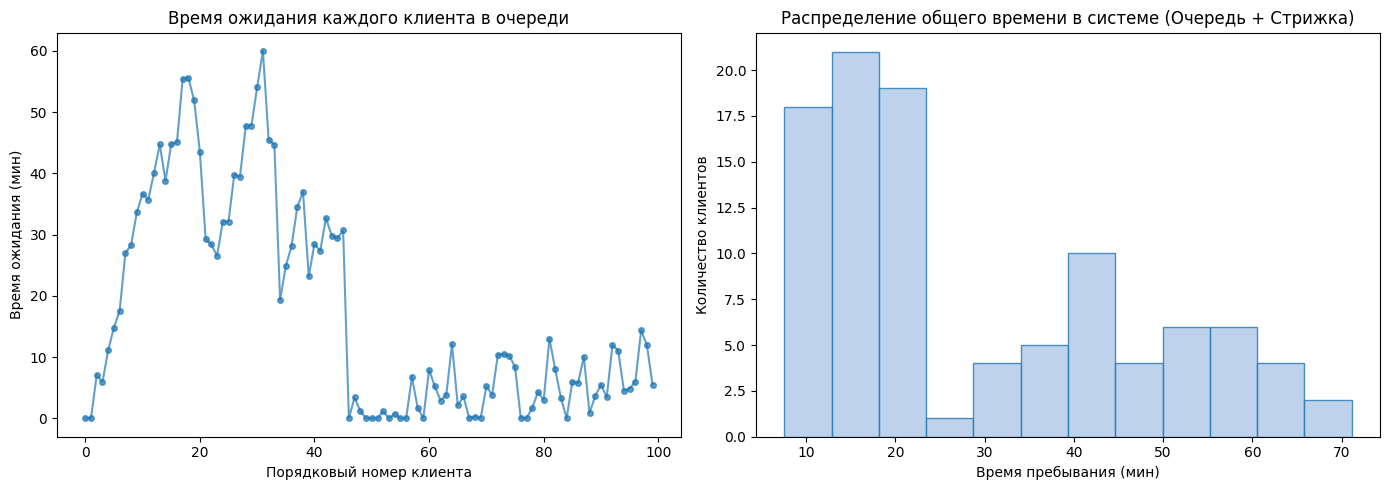

In [9]:
# Инициализация генератора случайных чисел для воспроизводимости
random.seed(RANDOM_SEED)

# Создание среды моделирования
env = simpy.Environment()

# Настройка склада (Store) с двумя неоднородными мастерами
barbers = simpy.Store(env, capacity=2)
br1 = Barber(1, [7.5, 12.5])  # Барбер 1 (быстрый): среднее время 10 мин (10 +/- 2.5)
br2 = Barber(2, [9.0, 17.0])  # Барбер 2 (медленный): среднее время 13 мин (13 +/- 4)
barbers.items = [br1, br2]

# Словари для накопления результатов
stats = {
    'wait_times': [],
    'total_times': []
}

# Запуск генератора клиентов
env.process(source(env, NUM_CUSTOMERS, ARRIVAL_MEAN, barbers, stats))

# Пошаговое выполнение модели до тех пор, пока 100 клиентов не пройдут обслуживание полностью
while len(stats['total_times']) < NUM_CUSTOMERS:
    env.step()

# Конечные метрики
end_time = env.now

print(f"Общее время моделирования (END TIME):   {end_time:.3f} мин")
print(f"Среднее время ожидания в очереди:       {np.mean(stats['wait_times']):.3f} мин")
print(f"Максимальное время ожидания:            {np.max(stats['wait_times']):.3f} мин")
print(f"Среднее время клиента в системе:        {np.mean(stats['total_times']):.3f} мин")
print("-" * 60)
print(f"Количество клиентов у Барбера 1 (Быстрый):    {br1.usages}")
print(f"Количество клиентов у Барбера 2 (Медленный):  {br2.usages}")
print("=" * 60)

# Построение графиков результатов
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Левый график: Динамика ожидания
axes[0].plot(stats['wait_times'], color='#1f77b4', marker='o', markersize=4, linestyle='-', alpha=0.7)
axes[0].set_title('Время ожидания каждого клиента в очереди')
axes[0].set_xlabel('Порядковый номер клиента')
axes[0].set_ylabel('Время ожидания (мин)')

# Правый график: Распределение общего времени
axes[1].hist(stats['total_times'], bins=12, color='#aec7e8', edgecolor='#1f77b4', alpha=0.8)
axes[1].set_title('Распределение общего времени в системе (Очередь + Стрижка)')
axes[1].set_xlabel('Время пребывания (мин)')
axes[1].set_ylabel('Количество клиентов')

plt.tight_layout()
plt.show()